# Relatedness
Using output from [variant_calling.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/variant_calling/variant_calling.ipynb), I'm going to visualize the relatedness between my samples to determine population structure.

The oysters used in this study all come from the Horn Point Laboratory. They're the same age with unknown ancestry, but presumably from a limited broodstock - so I'm expecting the oysters to be somewhat related  

## 0. load libraries

In [24]:
library(tidyverse)
library(pheatmap)
library(RColorBrewer)

## 1. read csv

this file was generated using [`vcftools`](https://vcftools.github.io/man_latest.html) and the -relatedness2 flag

In [21]:
rel <- read.csv('/scratch4/workspace/julia_mcdonough_student_uml_edu-novogene_dwnld/gatk/filtered/final_wMAF.relatedness2', sep ='\t')
head(rel)

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>
1,B1_B1_O01_gi,B1_B1_O01_gi,14314,0,14314,14314,0.50000000
2,B1_B1_O01_gi,B1_Nu_O03_gi,4732,2835,14314,13640,-0.03355510
3,B1_B1_O01_gi,B1_W5_O50_gi,4660,2855,14314,14801,-0.03606390
4,B1_B1_O01_gi,B2_B5_O51_gi,4628,2819,14314,13556,-0.03623970
5,B1_B1_O01_gi,B2_C4_O40_gi,5531,2830,14314,16630,-0.00416882
6,B1_B1_O01_gi,B2_Nu_O12_gi,4794,2736,14314,13269,-0.02458040


the RELATEDNESS_PHI column is the kinship coefficient

A negative kinship coefficient estimation indicates an unrelated relationship.

an estimated kinship coefficient range >0.354, [0.177, 0.354], [0.0884, 0.177] and [0.0442, 0.0884] corresponds to duplicate/MZ twin, 1st-degree, 2nd-degree, and 3rd-degree relationships respectively


## 2. visualizations

### pheatmap
with the color scale centered around 0

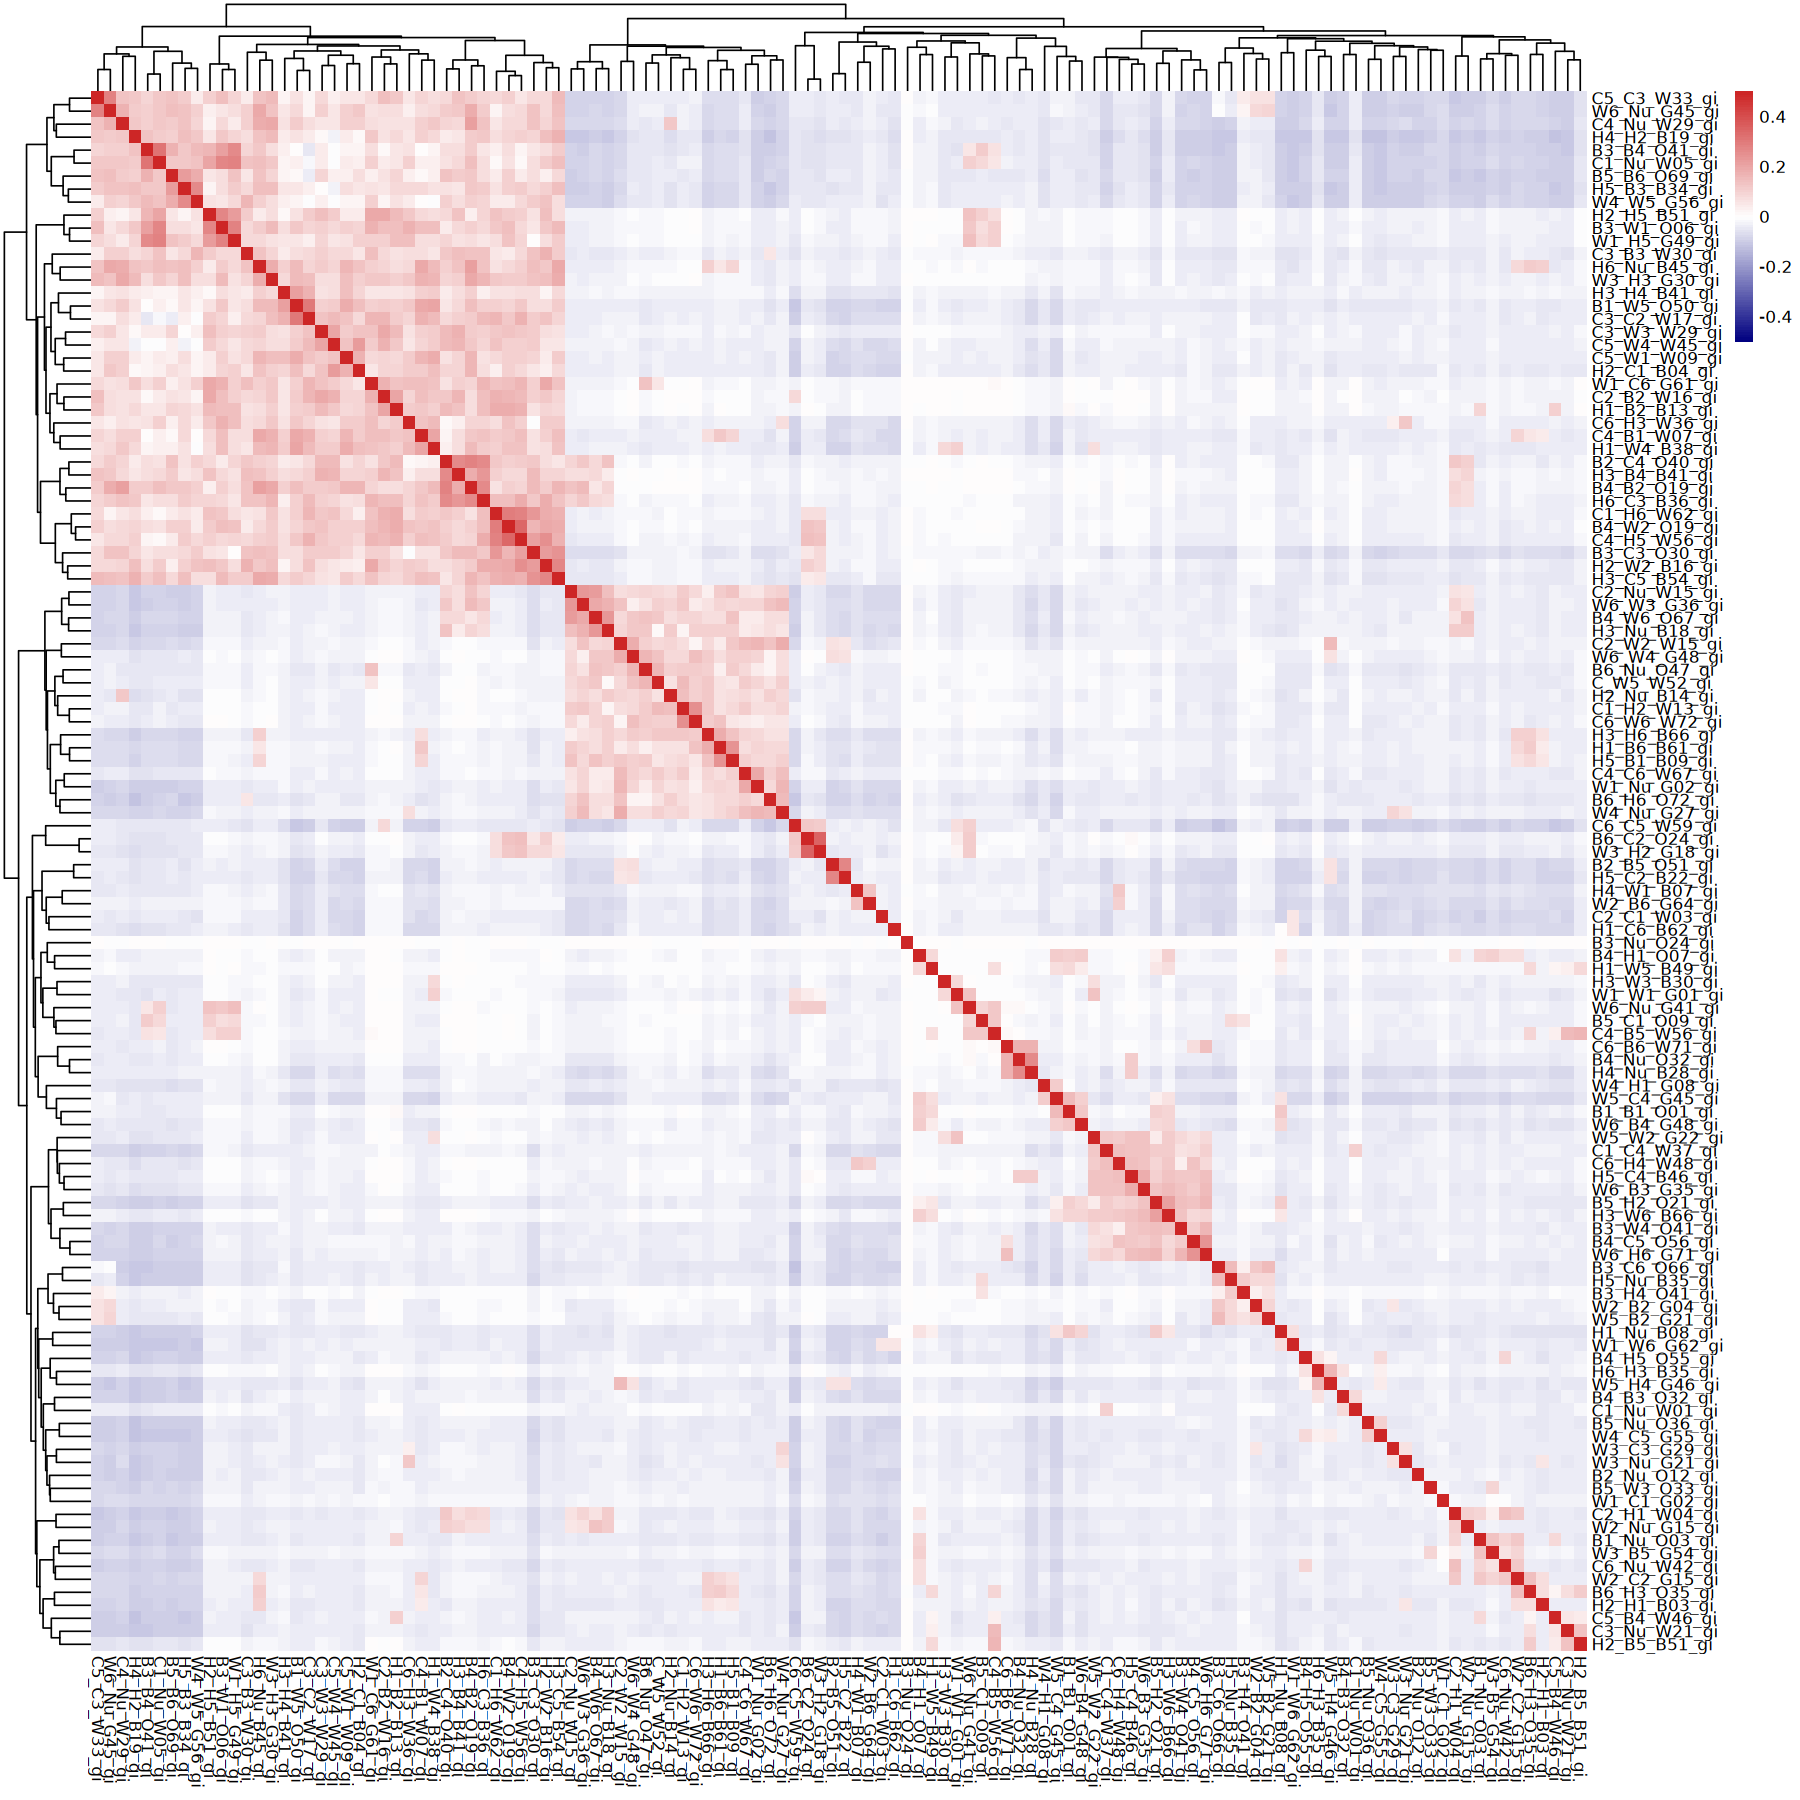

In [25]:
# 1. Determine the absolute maximum value to balance the scale
max_val <- max(abs(mat), na.rm = TRUE)

# 2. Create symmetric breaks from negative max to positive max
# 'pheatmap' requires length(breaks) == length(color) + 1
my_breaks <- seq(-max_val, max_val, length.out = 101)

# 3. Define a diverging color palette (e.g., Blue to White to Red)
my_colors <- colorRampPalette(c("navy", "white", "firebrick3"))(100)

# 4. Plot the heatmap
pheatmap(mat,
         color = my_colors,
         breaks = my_breaks)


according to online talk, a negative kinship coefficient means the samples are unrelated - so most oysters are not related to each other

there is some clusters of familiarity, especially in the top left - there's about 25ish oysters that seem to be related to each other

which is surprising?? I would expect the samples to be more related

so now - I think I should assign "subpopulations" (or maybe K clusters?) and plot GE data but colored by "subpopulation" and see if that explains GE more than the treatments 